In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [ ]:
cifar_dataset = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar_dataset
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [ ]:
CLASSES = ['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

/tmp/ipykernel_686/121563604.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


Text(0.5, 1.0, 'horse')

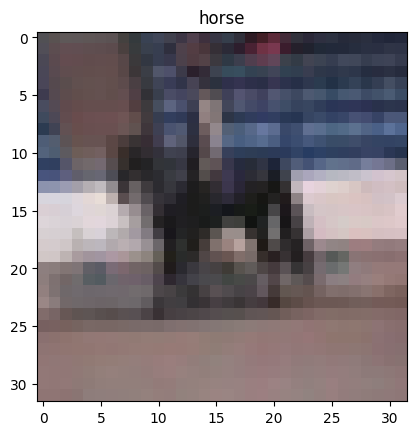

In [ ]:
RANDOM_INDEX = np.random.randint(0, len(x_train))
plt.imshow(x_train[RANDOM_INDEX]);
plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


/tmp/ipykernel_686/484476547.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


Text(0.5, 1.0, 'cat')

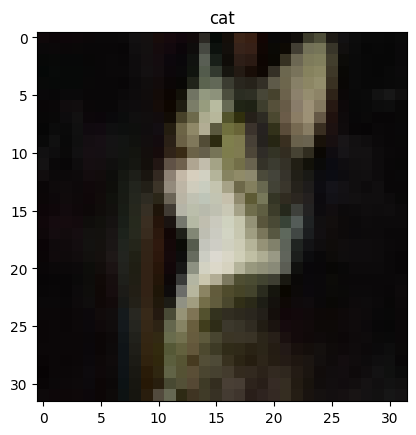

In [ ]:
RANDOM_INDEX = np.random.randint(0, len(x_train))
plt.imshow(x_train[RANDOM_INDEX]);
plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])

In [16]:
x_train[0].shape

(32, 32, 3)

In [17]:
architectura_cnn = tf.keras.models.Sequential([
    ## 28x28 -> pixeli
    ## 3- RGB
    tf.keras.layers.Input(shape=(32, 32, 3)),


    ## CNN
    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),
    ## Functie de activa -> relu. Initial s-a inceput cu tanh
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


     ### FULLY CONNECTED LAYERS
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=120, activation='relu'),
     ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),

])


architectura_cnn.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# 1. Pas de imbunatatire -> adaugarea mai multor date, prin creare unor date in memorie

In [12]:
architectura_cnn_cu_date_augumentate = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),


    ## Date Augumentate
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),


    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),

    ## CNN

    ## Functie de activa -> relu. Initial s-a inceput cu tanh
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


     ### FULLY CONNECTED LAYERS
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=120, activation='relu'),
     ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),

])


architectura_cnn.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [18]:
augumentation_layer = tf.keras.models.Sequential([
        ## Date Augumentate
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),

])
cnn_layer = tf.keras.models.Sequential([
        ## Functie de activa -> relu. Initial s-a inceput cu tanh
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
])

fc_layer = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=120, activation='relu'),
     ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),
])


arhitectura_modulara = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    ## LAYER DE AUGUMENTARE
    augumentation_layer,

    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),

    ## CNN
    cnn_layer,

     ### FULLY CONNECTED LAYER
    fc_layer
])
arhitectura_modulara.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])



In [19]:
architectura_cnn.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - accuracy: 0.4485 - loss: 1.5296 - val_accuracy: 0.5336 - val_loss: 1.3120
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5677 - loss: 1.2161 - val_accuracy: 0.6036 - val_loss: 1.1394
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.6238 - loss: 1.0729 - val_accuracy: 0.6284 - val_loss: 1.0643
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.6576 - loss: 0.9713 - val_accuracy: 0.6412 - val_loss: 1.0341
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.6866 - loss: 0.8885 - val_accuracy: 0.6325 - val_loss: 1.0770
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7101 - loss: 0.8284 - val_accuracy: 0.6641 - val_loss: 0.9747
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.7310 - loss: 0.7639 - val_accuracy: 0.6750 - val_loss: 0.9595
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.7484 -

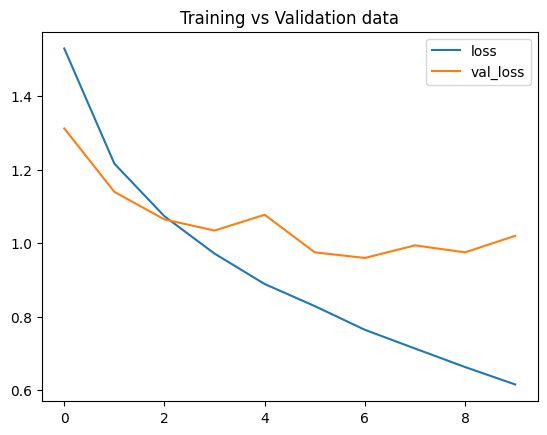

In [20]:
history_dict = architectura_cnn.history.history

loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Training vs Validation data")
plt.legend()
plt.show()


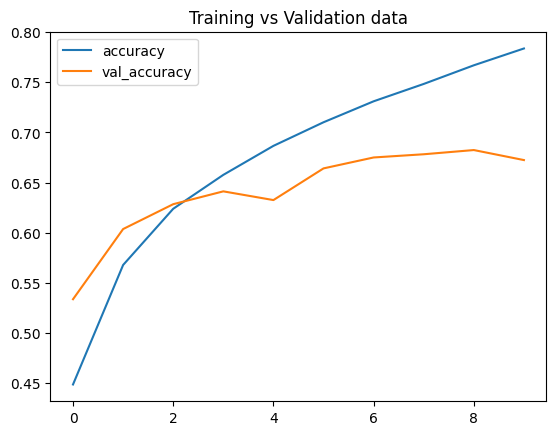

In [21]:
history_dict = architectura_cnn.history.history

loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


plt.plot(accuracy, label="accuracy")
plt.plot(val_accuracy, label="val_accuracy")
plt.title("Training vs Validation data")
plt.legend()
plt.show()

# 2. Pas de imbunatatire -> adaugarea mai multor epoci, si oprirea in caz ca nu invata intr-un numar de 5 epoci consecutiv

In [22]:
callback_option = tf.keras.callbacks.EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True)

arhitectura_modulara.fit(x_train, y_train, epochs=100, validation_split=0.2, callbacks=[callback_option])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 45ms/step - accuracy: 0.3420 - loss: 1.7926 - val_accuracy: 0.4185 - val_loss: 1.6232
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 45ms/step - accuracy: 0.4165 - loss: 1.5961 - val_accuracy: 0.4403 - val_loss: 1.5766
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.4514 - loss: 1.5115 - val_accuracy: 0.5029 - val_loss: 1.3844
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.4730 - loss: 1.4614 - val_accuracy: 0.4906 - val_loss: 1.4496
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.4900 - loss: 1.4157 - val_accuracy: 0.5105 - val_loss: 1.3569
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.4987 - loss: 1.3837 - val_accuracy: 0.5266 - val_loss: 1.3515
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.5126 - loss: 1.3583 - val_accuracy: 0.5493 - val_loss: 1.2752
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 

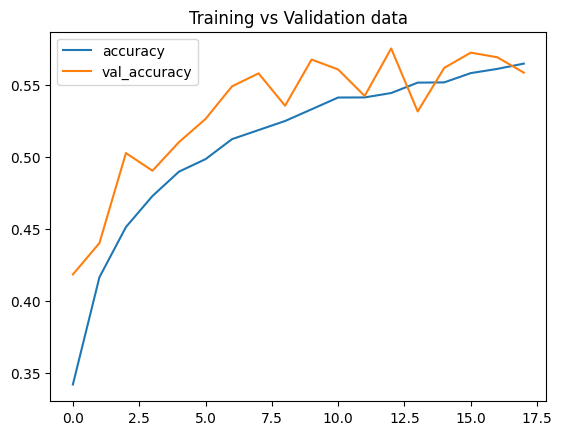

In [23]:
history_dict = arhitectura_modulara.history.history

loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


plt.plot(accuracy, label="accuracy")
plt.plot(val_accuracy, label="val_accuracy")
plt.title("Training vs Validation data")
plt.legend()
plt.show()

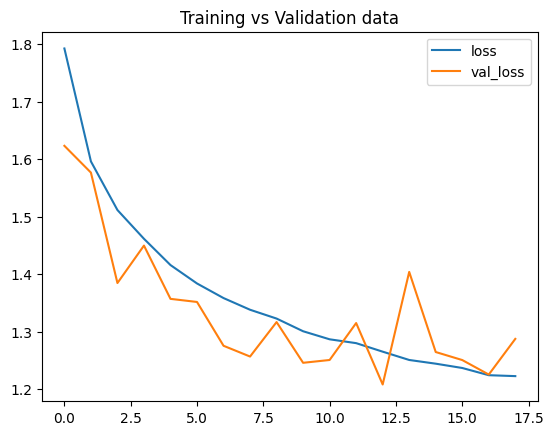

In [25]:
history_dict = arhitectura_modulara.history.history

loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Training vs Validation data")
plt.legend()
plt.show()


# 3. Pas de imbunatatire -> adaugarea mai multor layere in arhitectura modelului

In [26]:
augumentation_layer = tf.keras.models.Sequential([
        ## Date Augumentate
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),

])
cnn_layer = tf.keras.models.Sequential([
        ## Functie de activa -> relu. Initial s-a inceput cu tanh
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
])

fc_layer = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(units=256, activation='relu'),
     tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(units=128, activation='relu'),

    ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),
])


arhitectura_marita= tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    ## LAYER DE AUGUMENTARE
    augumentation_layer,

    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),

    ## CNN
    cnn_layer,

     ### FULLY CONNECTED LAYER
    fc_layer
])
arhitectura_marita.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [27]:
callback_option = tf.keras.callbacks.EarlyStopping(patience=7, monitor="val_loss", restore_best_weights=True)

arhitectura_marita.fit(x_train, y_train, epochs=100, validation_split=0.2, callbacks=[callback_option])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 69ms/step - accuracy: 0.3204 - loss: 1.8189 - val_accuracy: 0.3787 - val_loss: 1.7585
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.4172 - loss: 1.5963 - val_accuracy: 0.4860 - val_loss: 1.4282
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.4507 - loss: 1.5137 - val_accuracy: 0.4828 - val_loss: 1.4387
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.4722 - loss: 1.4683 - val_accuracy: 0.4696 - val_loss: 1.4922
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.4855 - loss: 1.4267 - val_accuracy: 0.5213 - val_loss: 1.3230
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.4957 - loss: 1.4028 - val_accuracy: 0.5179 - val_loss: 1.3495
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.5050 - loss: 1.3788 - val_accuracy: 0.5427 - val_loss: 1.2853
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 68ms/step - accuracy:

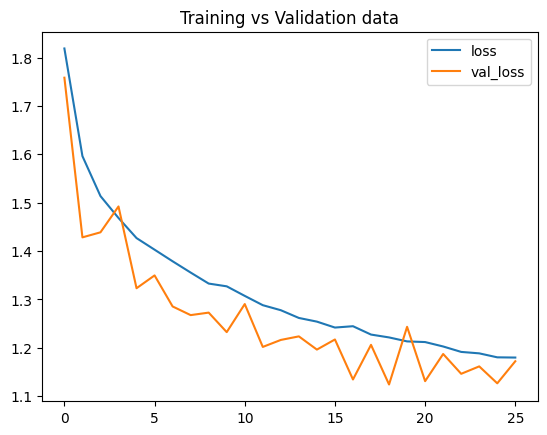

In [28]:


history_dict = arhitectura_marita.history.history

loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Training vs Validation data")
plt.legend()
plt.show()


In [29]:
arhitectura_marita.save("arhitectura_marita.h5")


In [30]:
arhitectura_marita.save("arhitectura_marita.keras")

In [31]:
# Citire fisier

In [33]:
model_citit = tf.keras.models.load_model("arhitectura_marita.keras")
model_citit

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Sequential name=sequential_15, built=True>

In [34]:
model_citit.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 6, 6, 32)       │        10,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ (None, 10)             │       755,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,531,990 (5.84 MB)

 Trainable params: 765,994 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 765,996 (2.92 MB)

In [35]:
augumentation_layer = tf.keras.models.Sequential([
    ## Date Augumentate
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    # Modificare 1: Am schimbat RandomFlip.
    # CIFAR-10 conține imagini reale (mașini, animale). Nu vrem să le întoarcem pe verticală
    # (cu susul în jos) pentru că modelul s-ar confunda.
    tf.keras.layers.RandomFlip("horizontal"),
])

cnn_layer = tf.keras.models.Sequential([
    # Modificare 2: Arhitectură mai adâncă de tip VGG, adăugare de Padding, BatchNormalization și Dropout
    # Bloc 1 de convoluție (32 filtre)
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(), # Normalizează activările și accelerează convergența
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25), # Regularizare spațială (aruncăm informație pentru a forța generalizarea)

    # Bloc 2 de convoluție (64 filtre)
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.35),

    # Bloc 3 de convoluție (128 filtre)
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.45),
])

fc_layer = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),

    # Modificare 3: Am redus unitățile din Dense pentru a preveni overfitting-ul major de la 512+256+128.
    # Un singur strat consistent (ex: 256) împreună cu Dropout mare este mult mai eficient.
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5), # 50% șanse ca neuronul curent să fie dezactivat pentru generalizare

    ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),
])

arhitectura_marita = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    ## LAYER DE AUGUMENTARE
    augumentation_layer,

    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),

    ## CNN
    cnn_layer,

    ### FULLY CONNECTED LAYER
    fc_layer
])

# Am explicitat Learning Rate-ul la compilare
arhitectura_marita.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [36]:
callback_option = tf.keras.callbacks.EarlyStopping(patience=7, monitor="val_loss", restore_best_weights=True)

arhitectura_marita.fit(x_train, y_train, epochs=100, validation_split=0.2, callbacks=[callback_option])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 357s 279ms/step - accuracy: 0.3457 - loss: 1.9151 - val_accuracy: 0.4157 - val_loss: 1.6618
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 380s 278ms/step - accuracy: 0.4615 - loss: 1.4862 - val_accuracy: 0.4742 - val_loss: 1.4505
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 379s 276ms/step - accuracy: 0.5170 - loss: 1.3479 - val_accuracy: 0.5114 - val_loss: 1.4161
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 349s 279ms/step - accuracy: 0.5561 - loss: 1.2512 - val_accuracy: 0.5805 - val_loss: 1.2083
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 381s 278ms/step - accuracy: 0.5790 - loss: 1.1868 - val_accuracy: 0.6125 - val_loss: 1.1254
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 347s 277ms/step - accuracy: 0.6083 - loss: 1.1141 - val_accuracy: 0.5945 - val_loss: 1.2375
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 380s 276ms/step - accuracy: 0.6240 - loss: 1.0652 - val_accuracy: 0.6420 - val_loss: 1.0628
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 393s 285ms/s

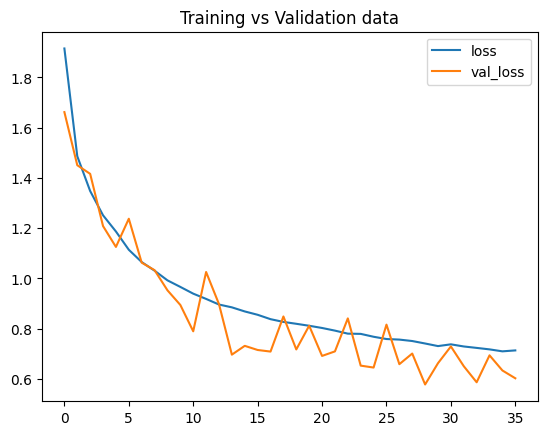

In [37]:


history_dict = arhitectura_marita.history.history

loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


loss =  history_dict["loss"]
val_loss = history_dict["val_loss"]
accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]


plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Training vs Validation data")
plt.legend()
plt.show()
